In [1]:
import math as maths

import cartopy.crs as ccrs
import intake
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

import easygems.healpix as egh

/home/users/mmuetz/miniforge3/envs/hackathon_env/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [2]:
import warnings

# Suppress specific FutureWarnings matching the message pattern when using cat[...].to_dask()
warnings.filterwarnings(
    "ignore",
    message=".*The return type of `Dataset.dims` will be changed.*",
    category=FutureWarning,
)

In [4]:
# Show UM sims:
[key for key in cat if key.startswith('um_')]

['um_Africa_km4p4_RAL3P3_n1280_GAL9_nest',
 'um_CTC_km4p4_RAL3P3_n1280_GAL9_nest',
 'um_SAmer_km4p4_RAL3P3_n1280_GAL9_nest',
 'um_SEA_km4p4_RAL3P3_n1280_GAL9_nest',
 'um_glm_n1280_CoMA9_TBv1p2',
 'um_glm_n1280_GAL9',
 'um_glm_n2560_RAL3p3']

In [5]:
# Show example URL
cat['um_glm_n2560_RAL3p3'](zoom=0, time='PT1H').urlpath

'https://hackathon-o.s3-ext.jc.rl.ac.uk/sim-data/dev/v5/glm.n2560_RAL3p3/um.PT1H.hp_z0.zarr'

In [1]:
import intake
cat = intake.open_catalog('https://digital-earths-global-hackathon.github.io/catalog/catalog.yaml')['online']
ds = cat['um_glm_n2560_RAL3p3'](zoom=10, time='PT3H', chunks='auto').to_dask()

/home/users/mmuetz/miniforge3/envs/hackathon_env/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)
/home/users/mmuetz/miniforge3/envs/hackathon_env/lib/python3.12/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dims': dict(self._ds.dims),


In [2]:
ds

<xarray.Dataset> Size: 53TB
Dimensions:   (cell: 12582912, time: 3497, pressure: 25)
Coordinates:
  * cell      (cell) int64 101MB 0 1 2 3 ... 12582908 12582909 12582910 12582911
    crs       float64 8B ...
  * pressure  (pressure) int64 200B 1 5 10 20 30 50 ... 875 900 925 950 975 1000
  * time      (time) datetime64[ns] 28kB 2020-01-20 ... 2021-04-01
Data variables:
    cli       (time, pressure, cell) float32 4TB dask.array<chunksize=(3, 3, 3145728), meta=np.ndarray>
    clw       (time, pressure, cell) float32 4TB dask.array<chunksize=(3, 3, 3145728), meta=np.ndarray>
    hur       (time, pressure, cell) float32 4TB dask.array<chunksize=(3, 3, 3145728), meta=np.ndarray>
    hus       (time, pressure, cell) float32 4TB dask.array<chunksize=(3, 3, 3145728), meta=np.ndarray>
    qg        (time, pressure, cell) float32 4TB dask.array<chunksize=(3, 3, 3145728), meta=np.ndarray>
    qr        (time, pressure, cell) float32 4TB dask.array<chunksize=(3, 3, 3145728), meta=np.ndarray>
    qs        (time, pressure, cell) float32 4TB dask.array<chunksize=(3, 3, 3145728), meta=np.ndarray>
    ta        (time, pressure, cell) float32 4TB dask.array<chunksize=(3, 3, 3145728), meta=np.ndarray>
    ua        (time, pressure, cell) float32 4TB dask.array<chunksize=(3, 3, 3145728), meta=np.ndarray>
    va        (time, pressure, cell) float32 4TB dask.array<chunksize=(3, 3, 3145728), meta=np.ndarray>
    wa        (time, pressure, cell) float32 4TB dask.array<chunksize=(3, 3, 3145728), meta=np.ndarray>
    zg        (time, pressure, cell) float32 4TB dask.array<chunksize=(3, 3, 3145728), meta=np.ndarray>
Attributes:
    Met Office DYAMOND3 simulations:  A group of experiments have been conduc...
    bounds:                           {'lower_left_lat': -90, 'lower_left_lon...
    latitiude_convention:             [-90, 90]
    longitude_convention:             [0, 360]
    regional:                         False
    simulation:                       glm.n2560_RAL3p3
    simulation_description:           The MetUM uses a regular lat-lon grid, ...

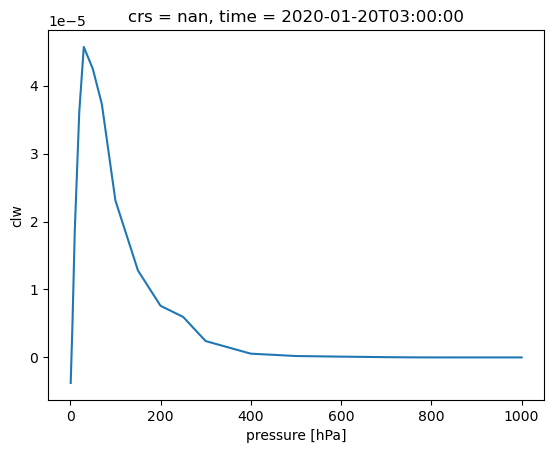

In [6]:
ds.isel(time=1).clw.mean(dim='cell').plot()

In [4]:
def fix_interp_pressure_fields(da):
    if da.name in {'cli', 'clw', 'qg', 'qr', 'qs'}:
        return da.assign_coords(pressure=da.pressure[::-1])
    return da
ds2 = ds.map(fix_interp_pressure_fields)

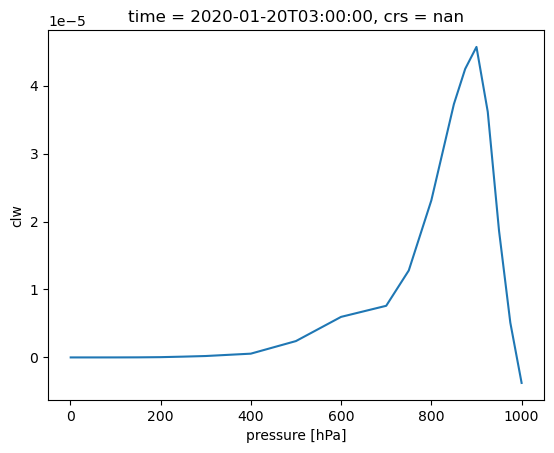

In [5]:
ds2.isel(time=1).clw.mean(dim='cell').plot()

In [18]:
{n: da.attrs['long_name'] for n, da in ds.data_vars.items()}

{'cli': 'mass_fraction_of_cloud_ice_in_air',
 'clw': 'mass_fraction_of_cloud_liquid_water_in_air',
 'hur': 'relative_humidity',
 'hus': 'specific_humidity',
 'qg': 'mass_fraction_of_graupel_in_air',
 'qr': 'mass_fraction_of_rain_in_air',
 'qs': 'mass_fraction_of_snow_water_in_air',
 'ta': 'temperature',
 'ua': 'eastward_wind',
 'va': 'northtward_wind',
 'wa': 'upward_air_velocity',
 'zg': 'geopotential height'}

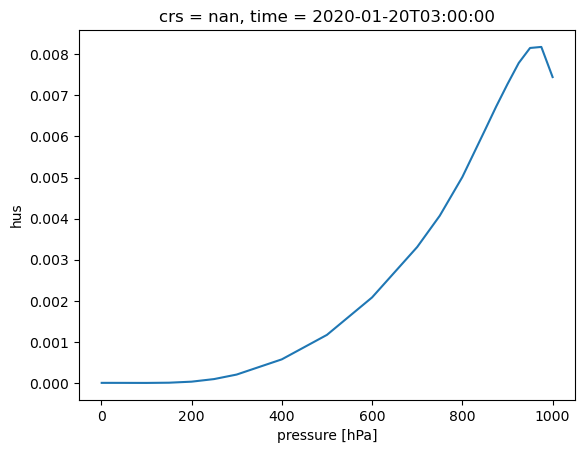

In [19]:
ds.isel(time=1).hus.mean(dim='cell').plot()

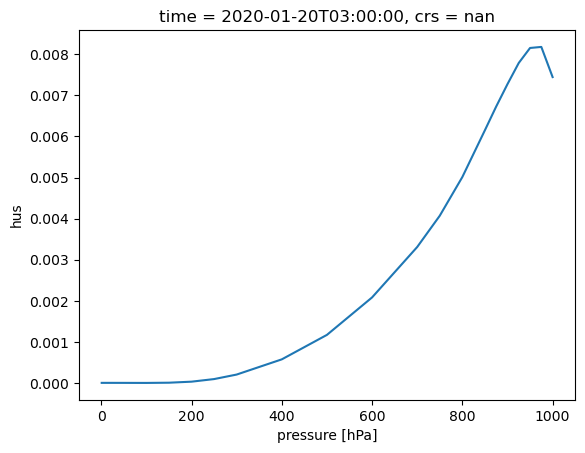

In [20]:
ds2.isel(time=1).hus.mean(dim='cell').plot()

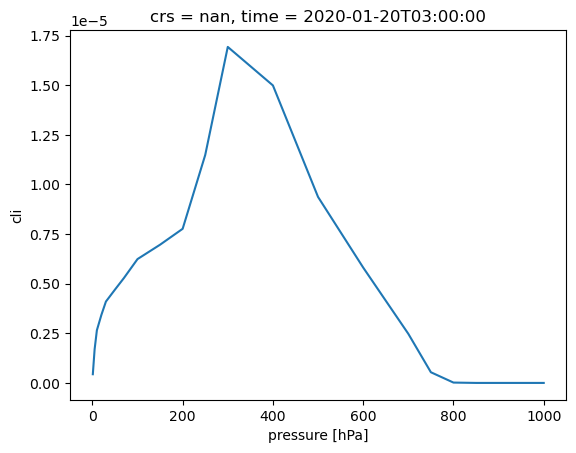

In [23]:
ds.isel(time=1).cli.mean(dim='cell').plot()

In [25]:
def fix_interp_pressure_fields2(da):
    if da.name in {'cli', 'clw', 'qg', 'qr', 'qs'}:
        return da.isel(pressure=slice(None, None, -1))
    return da
ds3 = ds.map(fix_interp_pressure_fields2)

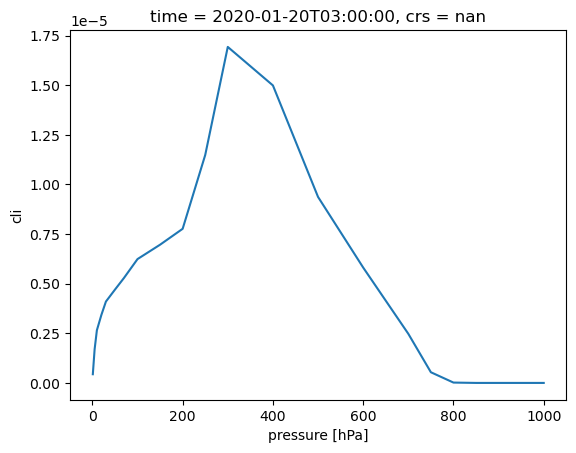

In [26]:
ds3.isel(time=1).cli.mean(dim='cell').plot()

In [ ]:
ds3.isel(time=1).cli.mean(dim='cell').plot()

In [29]:
ds4 = ds.assign_coords(pressure_flipped=ds.pressure[::-1])

In [31]:
ds4.cli.dims

('time', 'pressure', 'cell')